In [53]:
# Description: This program uses an artificial recurrent neural networks called 
# RNN (Recurrent Neural Networks)
# LSTM (Long Short Term Memory Networks)
# GRU (Gated Recurrent Unit Network)
# to predict the closing stock price of a corporation (Apple Inc.) using the past 60 day stock price.

#Import the libraries
import math
import yfinance as yfn
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, GRU, RNN
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [54]:
#Get the stock quote 

# Model types "RNN" "LSTM" or "GRU" 
model_type = "RNN"

# Share name for prediction "IBM", "MGLU3.SA"
share_name = 'AAPL'

# Dates for model prediction
share_dt_start = '2015-01-01'
share_dt_end = '2021-08-31'
share_pr_start = '2021-08-31'
share_pr_end = '2021-12-31'
df = yfn.download(share_name, start = share_dt_start, end = share_dt_end)

#Show the data 
df

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-01-02,27.847500,27.860001,26.837500,27.332500,24.782110,212818400
2015-01-05,27.072500,27.162500,26.352501,26.562500,24.083958,257142000
2015-01-06,26.635000,26.857500,26.157499,26.565001,24.086227,263188400
2015-01-07,26.799999,27.049999,26.674999,26.937500,24.423975,160423600
2015-01-08,27.307501,28.037500,27.174999,27.972500,25.362394,237458000
...,...,...,...,...,...,...
2021-08-24,149.449997,150.860001,149.149994,149.619995,149.619995,48606400
2021-08-25,149.809998,150.320007,147.800003,148.360001,148.360001,58991300
2021-08-26,148.350006,149.119995,147.509995,147.539993,147.539993,48597200


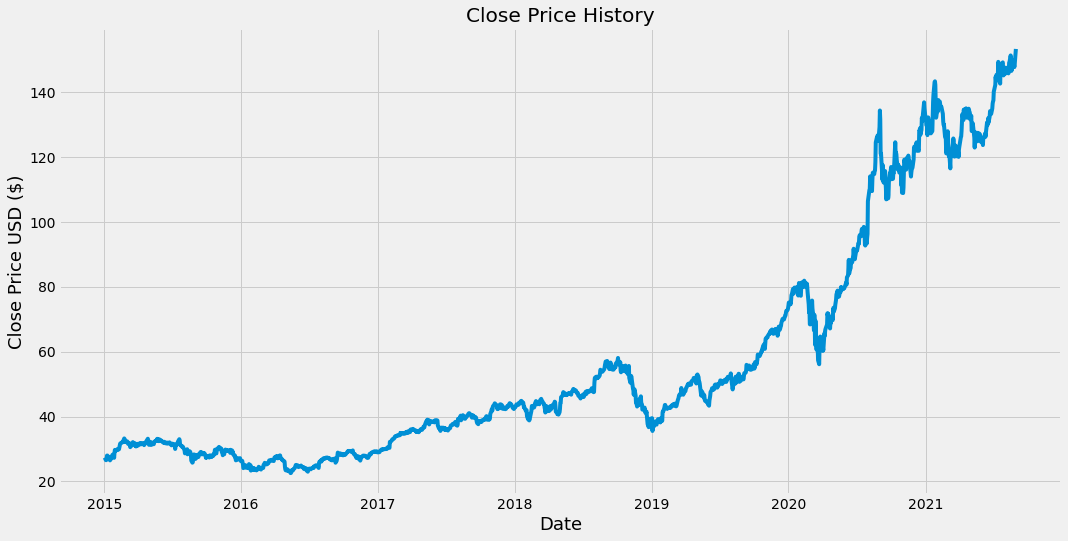

In [55]:

#Visualize the closing price history
plt.figure(figsize = (16,8))
plt.title('Close Price History')
plt.plot(df['Close'])
plt.xlabel('Date', fontsize = 18)
plt.ylabel('Close Price USD ($)', fontsize = 18)
plt.show()

In [56]:
#Create a new dataframe with only the 'Close' column
data = df.filter(['Close']) 
#Converting the dataframe to a numpy array
dataset = data.values 
#Get/Compute the number of rows to train the model on
training_data_len = math.ceil( len(dataset) *.8) 

#Scale the all of the data to be values between 0 and 1 
scaler = MinMaxScaler(feature_range = (0, 1)) 
scaled_data = scaler.fit_transform(dataset)
#Show scaled data
scaled_data

array([[0.03636957],
       [0.03047076],
       [0.03048992],
       ...,
       [0.95725283],
       [0.96537335],
       [1.        ]])

In [57]:
#Create the scaled training data set 
train_data = scaled_data[0:training_data_len  , : ] #Split the data into x_train and y_train data sets
x_train = []
y_train = []
for i in range(100,len(train_data)):
    x_train.append(train_data[i-100:i,0])
    y_train.append(train_data[i,0])

#Convert x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

#Reshape the data into the shape accepted by the LSTM
x_train = np.reshape(x_train, (x_train.shape[0],x_train.shape[1],1))

#Build the LSTM network model
model = Sequential()
if model_type == "RNN":
    model.add(LSTM(units = 50, return_sequences = True,input_shape = (x_train.shape[1],1)))
    model.add(LSTM(units = 50, return_sequences = False))
elif model_type == "LSTM":
    model.add(LSTM(units = 50, return_sequences = True,input_shape = (x_train.shape[1],1)))
    model.add(LSTM(units = 50, return_sequences = False))
elif model_type == "GRU":
    model.add(GRU(units = 50, return_sequences = True,input_shape = (x_train.shape[1],1)))
    model.add(GRU(units = 50, return_sequences = False))
else:
    print("No valid model.")
model.add(Dense(units = 25))
model.add(Dense(units = 1))

#Compile the model
model.compile(optimizer = 'adam',
              loss = 'mean_squared_error',
              metrics = ['accuracy'])
#Train the model
model.fit(x_train, y_train, batch_size = 1, epochs = 1)

1242/1242 [==============================] - 25s 19ms/step - loss: 5.6945e-04 - accuracy: 8.0515e-04


In [58]:
#Test data set
test_data = scaled_data[training_data_len - 60: , : ] 
#Create the x_test and y_test data sets
x_test = []
y_test =  dataset[training_data_len : , : ] 
#Get all of the rows from index 1603 to the rest and all of the columns 
#(in this case it's only column 'Close'), so 2003 - 1603 = 400 rows of data
for i in range(60,len(test_data)):
    x_test.append(test_data[i-60:i,0])

#Convert x_test to a numpy array 
x_test = np.array(x_test)

#Reshape the data into the shape accepted by the LSTM 3D 
#[number of samples, number of time steps and number of features].
x_test = np.reshape(x_test, (x_test.shape[0],x_test.shape[1],1))

#Getting the models predicted price values
predictions = model.predict(x_test) 
#Undo scaling
predictions = scaler.inverse_transform(predictions) 

#The RMSE is the square root of the variance of the residuals. 
#It indicates the absolute fit of the model to the data, 
#how close the observed data points are to the model's predicted values.
#Normally a RMSE > 0.5 is related to a bad predictive model.

#You can use the following statements to calculate RMSE:
#1. rmse = np.sqrt(np.mean(((predictions- y_test)**2)))
#2. rmse = np.sqrt(np.mean(np.power((np.array(y_test)-np.array(predictions)),2)))
#3. rmse = np.sqrt(((predictions - y_test) ** 2).mean())
#4. rmse = np.sqrt(np.mean(((predictions- y_test)**2))

#Calculate/Get the value of RMSE
rmse = np.sqrt(np.mean((predictions- y_test)**2))
#Show scaled data
print('RMSE < 0.5 is related to a good predictive model')
print('================================================')
print('RMSE:', rmse)
print('================================================')

RMSE < 0.5 is related to a good predictive model
RMSE: 4.768870418327647


C:\Windows\TEMP/ipykernel_12176/1154464018.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


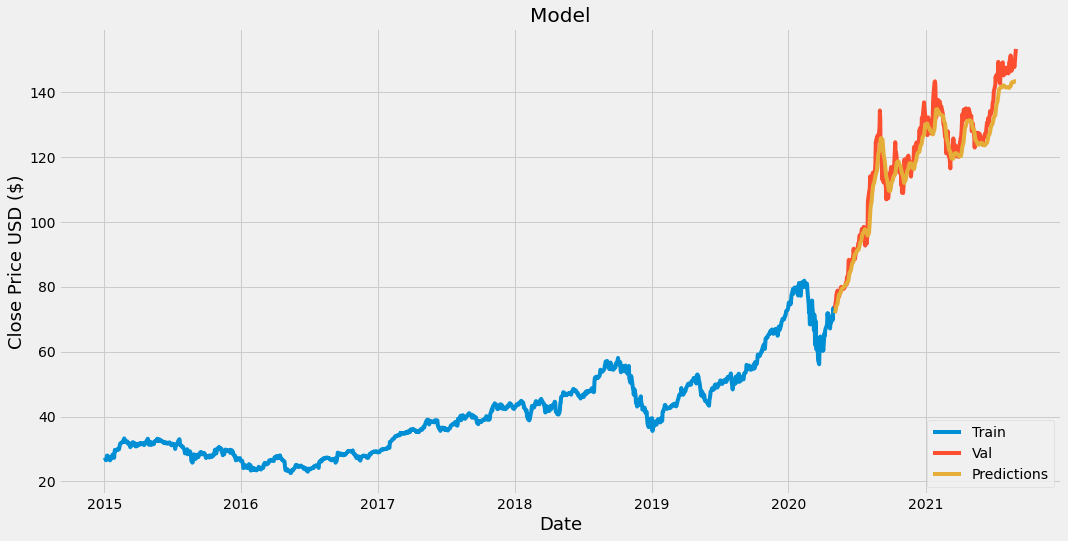

In [59]:
#Plot/Create the data for the graph
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions 
#Visualize the data
plt.figure(figsize = (16,8))
plt.title('Model')
plt.xlabel('Date', fontsize = 18)
plt.ylabel('Close Price USD ($)', fontsize = 18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc = 'lower right')
plt.show()

In [60]:
#Show the valid and predicted prices
valid

,Close,Predictions
Date,,
2020-05-04,73.290001,71.798256
2020-05-05,74.389999,72.230743
2020-05-06,75.157501,72.747459
2020-05-07,75.934998,73.336670
2020-05-08,77.532501,73.987206
...,...,...
2021-08-24,149.619995,142.956131
2021-08-25,148.360001,143.122360
2021-08-26,147.539993,143.194748


In [61]:
#Get the quote [predicted price]
share_quote = yfn.download(share_name, start = share_dt_start, end = share_dt_end)
#Create a new dataframe
new_df = share_quote.filter(['Close']) 
#Get teh last 60 day closing price 
last_60_days = new_df[-60:].values 
#Scale the data to be values between 0 and 1
last_60_days_scaled = scaler.transform(last_60_days) 
#Create an empty list
X_test = [] 
#Append teh past 60 days
X_test.append(last_60_days_scaled) 
#Convert the X_test data set to a numpy array
X_test = np.array(X_test) 
#Reshape the data
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1)) 
#Get the predicted scaled price
pred_price = model.predict(X_test) 
#Undo the scaling 
pred_price = scaler.inverse_transform(pred_price)
#Show the predicted price
print('Predicted price:', pred_price)

[*********************100%***********************]  1 of 1 completed
Predicted price: [[143.48647]]


In [62]:
#Get the quote [real price]
share_nquote = yfn.download(share_name, start = share_pr_start, end = share_pr_end)

#Show the real price
print('Real Price: ', share_nquote['Close'])

[*********************100%***********************]  1 of 1 completed
Real Price:  Date
2021-08-31    151.830002
Name: Close, dtype: float64
